<span style="color: blue;font-size: 32px; " title="Capstone Project: End-to-End Data Science Project">
  <strong>Capstone Project End-to-End Data Science Project </strong>
</span>


## Presented by --- ALBIN K A

### Project Overview:

### Objective: Use data science to analyze product data and uncover market trends and customer preferences. 
### Goal: Improve product offerings and optimize marketing strategies. 
### Scope: Data collection, analysis, and machine learning to deliver actionable insights.

<br> <<< --------------------------------------------------------------------------------------------------------------------------------------------- >>>

## 1. Web Scraping

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
url = "https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

product_data = []

for item in soup.select(".thumbnail"):  # update selector based on site
    name = item.select_one('.title').text.strip()
    price = item.select_one('.price').text.strip().replace("$", "")
    category = "Laptops"
    rating = len(item.select(".glyphicon-star"))
    reviews = item.select_one('.ratings > p').text.strip().split()[0] 
    
    product_data.append([name, price, category, rating, reviews])

df = pd.DataFrame(product_data, columns=["Name", "Price", "Category", "Rating", "Reviews"])
df.to_csv("products.csv", index=False)

<br>

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Base URLs with pagination support
base_urls = {
    "Laptops": "https://webscraper.io/test-sites/e-commerce/static/computers/laptops",
    "Tablets": "https://webscraper.io/test-sites/e-commerce/static/computers/tablets",
    "Phones": "https://webscraper.io/test-sites/e-commerce/static/phones/touch"
}

all_products = []

# Loop through categories and their base URLs
for category, base_url in base_urls.items():
    for page in range(1, 10): # Trying up to 10 pages (adjust as needed)
        paginated_url = f"{base_url}?page={page}"
        response = requests.get(paginated_url)
        soup = BeautifulSoup(response.content, "html.parser")

        products = soup.select(".thumbnail")
        if not products:
            break # No more products, stop further paging

        for item in products:
            name = item.select_one(".title").text.strip()
            price = item.select_one(".price").text.strip().replace("$", "")
            rating = len(item.select(".ws-icon-star"))
            reviews = item.select_one(".ratings > p").text.strip().split()[0]

            all_products.append({
                "Product Name": name,
                "Price": float(price),
                "Category": category,
                "Ratings": rating,
                "Number of Reviews": int(reviews)
            })

# Create final Dataframes:
df = pd.DataFrame(all_products)
df.to_csv("all_products.csv", index=False)

#### Successfuly completed web scraping!

## 2. Data Cleaning

In [3]:
import pandas as pd

df = pd.read_csv("all_products.csv")
df.head()

,Product Name,Price,Category,Ratings,Number of Reviews
0,Packard 255 G2,416.99,Laptops,0,2
1,Aspire E1-510,306.99,Laptops,0,2
2,ThinkPad T540p,1178.99,Laptops,0,2
3,ProBook,739.99,Laptops,0,8
4,ThinkPad X240,1311.99,Laptops,0,12


In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df.isnull().sum()  # Check missing data

Product Name         0
Price                0
Category             0
Ratings              0
Number of Reviews    0
dtype: int64

In [6]:
df['Price'] = df['Price'].astype(float) #Convert types: Ensure numeric fields are correctly typed for analysis.
df['Number of Reviews'] = df['Number of Reviews'].astype(int)


In [7]:
df['Product Name'] = df['Product Name'].str.strip() #Strip whitespace / clean strings: Tidy up names, categories.
df.rename(columns={'Product Name': 'Name'}, inplace=True) #Rename columns: For better readability


In [8]:
df.head()

,Name,Price,Category,Ratings,Number of Reviews
0,Packard 255 G2,416.99,Laptops,0,2
1,Aspire E1-510,306.99,Laptops,0,2
2,ThinkPad T540p,1178.99,Laptops,0,2
3,ProBook,739.99,Laptops,0,8
4,ThinkPad X240,1311.99,Laptops,0,12


## 3. Exploratory Data Analysis (EDA)

In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               84 non-null     object 
 1   Price              84 non-null     float64
 2   Category           84 non-null     object 
 3   Ratings            84 non-null     int64  
 4   Number of Reviews  84 non-null     int32  
dtypes: float64(1), int32(1), int64(1), object(2)
memory usage: 3.1+ KB


,Price,Ratings,Number of Reviews
count,84.000000,84.0,84.000000
mean,536.468929,0.0,7.154762
std,409.244547,0.0,4.146399
min,24.990000,0.0,0.000000
25%,298.247500,0.0,3.000000
50%,425.145000,0.0,7.500000
75%,691.500000,0.0,10.000000
max,1799.000000,0.0,14.000000


<Axes: title={'center': 'Product Counts by Category'}, xlabel='Category'>

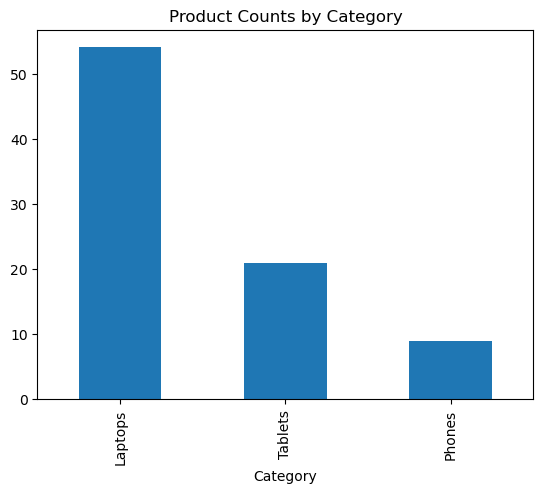

In [10]:
df['Category'].value_counts().plot(kind='bar', title='Product Counts by Category') #Category Distribution


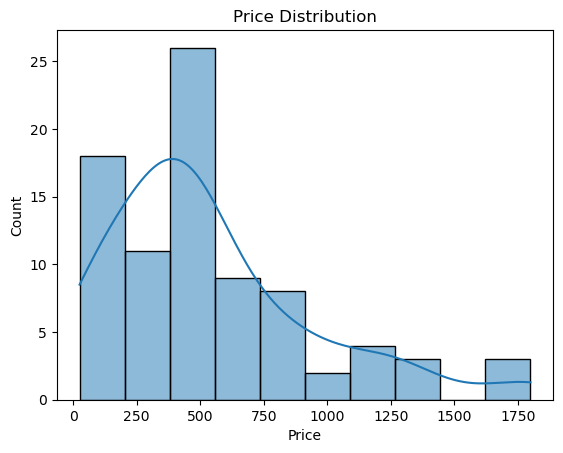

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt #Price Distribution

sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.show()


In [12]:
df.groupby('Category')['Price'].mean() #Category-based aggregation


Category
Laptops    677.494259
Phones     400.656667
Tablets    232.037619
Name: Price, dtype: float64

Text(0.5, 1.0, 'Price Spread by Category')

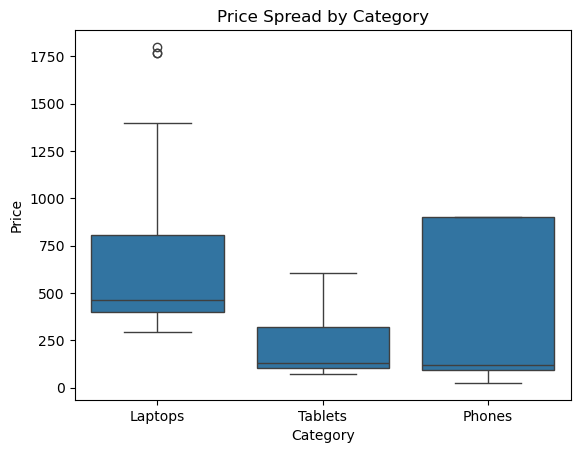

In [13]:
sns.boxplot(data=df, x='Category', y='Price') #Price Comparisons by Category
plt.title("Price Spread by Category")


In [14]:
df.corr(numeric_only=True)


,Price,Ratings,Number of Reviews
Price,1.000000,NaN,-0.016185
Ratings,NaN,NaN,NaN
Number of Reviews,-0.016185,NaN,1.000000


In [32]:
df.sort_values(by='Number of Reviews', ascending=False).head(10)


,Name,Price,Category,Ratings,Number of Reviews
29,Asus VivoBook...,295.99,Laptops,0,14
60,Galaxy Tab,251.99,Tablets,0,14
56,Asus MeMO Pad,102.99,Tablets,0,14
44,Acer Aspire ES...,410.46,Laptops,0,14
66,Galaxy Tab 3,107.99,Tablets,0,14
15,Dell Vostro 15,488.78,Laptops,0,14
11,HP 250 G3,520.99,Laptops,0,13
6,ThinkPad Yoga,1033.99,Laptops,0,13
72,IdeaTab A8-50,121.99,Tablets,0,13
4,ThinkPad X240,1311.99,Laptops,0,12


In [19]:
df.to_csv("cleaned_products.csv", index=False, encoding="utf-8")

<br>

## 4.Unsupervised Learning (Clustering)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler

# Load the Library for KMeans Clustering
from sklearn.cluster import KMeans

In [19]:
import pandas as pd
df = pd.read_csv("cleaned_products.csv", encoding="utf-8")
df

,Name,Price,Category,Ratings,Number of Reviews
0,Packard 255 G2,416.99,Laptops,0,2
1,Aspire E1-510,306.99,Laptops,0,2
2,ThinkPad T540p,1178.99,Laptops,0,2
3,ProBook,739.99,Laptops,0,8
4,ThinkPad X240,1311.99,Laptops,0,12
...,...,...,...,...,...
79,Sony Xperia,118.99,Phones,0,6
80,Ubuntu Edge,499.99,Phones,0,2
81,Iphone,899.99,Phones,0,10
82,Iphone,899.99,Phones,0,8


In [20]:
# Data Preprocessing : 

X = df[['Price', 'Number of Reviews']]

# Scaling The Features 

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

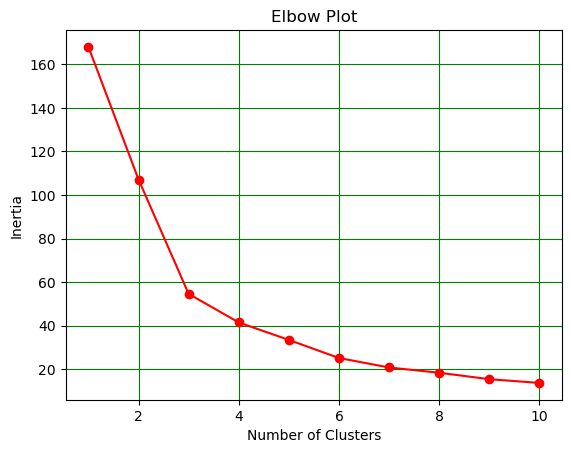

In [21]:
# Use Elbow Method / PLot to identify K Value : 

from warnings import filterwarnings
filterwarnings('ignore')
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elobow Curve:
plt.plot(range(1, 11), inertia, marker = 'o', color = 'r')
plt.title('Elbow Plot')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(color = 'g')
plt.show()

Since Elbow plot shows k = 5

In [22]:
kmeans = KMeans(n_clusters = 5, random_state = 42)
df['groups'] = kmeans.fit_predict(x_scaled)

In [23]:
df

,Name,Price,Category,Ratings,Number of Reviews,groups
0,Packard 255 G2,416.99,Laptops,0,2,1
1,Aspire E1-510,306.99,Laptops,0,2,1
2,ThinkPad T540p,1178.99,Laptops,0,2,4
3,ProBook,739.99,Laptops,0,8,3
4,ThinkPad X240,1311.99,Laptops,0,12,2
...,...,...,...,...,...,...
79,Sony Xperia,118.99,Phones,0,6,3
80,Ubuntu Edge,499.99,Phones,0,2,1
81,Iphone,899.99,Phones,0,10,2
82,Iphone,899.99,Phones,0,8,3


<br>


## 5. Supervised Learning

In [24]:
import pandas as pd
import numpy as np
X = df[['Price', 'Ratings', 'Number of Reviews']]
y = df['Category']


In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


models = {
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'k-NN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(),
    
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")


Logistic Regression trained.
SVM trained.
k-NN trained.
Random Forest trained.


In [15]:
from sklearn.metrics import accuracy_score, f1_score

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"{name}: Accuracy={acc:.2f}, F1 Score={f1:.2f}")


Logistic Regression: Accuracy=0.76, F1 Score=0.73
SVM: Accuracy=0.82, F1 Score=0.79
k-NN: Accuracy=0.76, F1 Score=0.73
Random Forest: Accuracy=0.76, F1 Score=0.73


## 6. Hyperparameter Tuning

In [30]:
from sklearn.metrics import accuracy_score

model_accuracies = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_accuracies[name] = acc


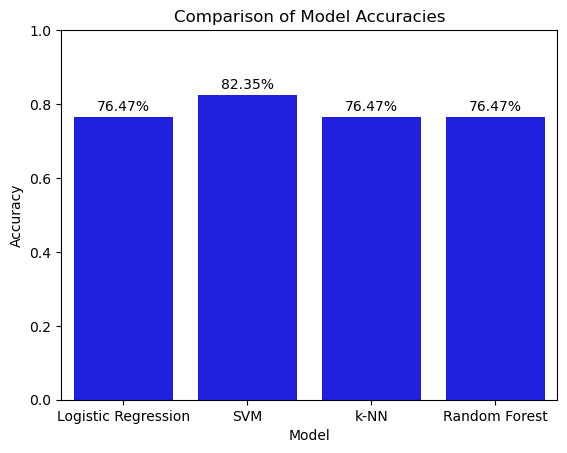

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=list(model_accuracies.keys()), 
            y=list(model_accuracies.values()), color='b')
# Add data labels on top of each bar
for i, (model, acc) in enumerate(model_accuracies.items()):
    plt.text(i, acc + 0.01, f"{acc*100:.2f}%", ha='center', va='bottom', fontsize=10, color='black')
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Comparison of Model Accuracies")
plt.ylim(0, 1)
plt.show()
